<a href="https://colab.research.google.com/github/Knchna/ICT_AI-ML/blob/main/Jul_13_Intermediate_Assessment_2_Supervised_Learning_on_Heart_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split

# classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# regression


# Reading Dataset

In [5]:
filepath = "/content/drive/MyDrive/ICT_AIML Class/Datasets/heart_disease.csv"

In [6]:
df_heart = pd.read_csv(filepath)
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# EDA

In [7]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
# Inference:
  # No missing values are there

In [8]:
df_heart.shape

(1025, 14)

In [9]:
df_heart.columns.tolist()

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

In [ ]:
# Column Details:
'''
age: Age of the individual
sex: Gender of the individual (0 = female, 1 = male)
chest pain type: Type of chest pain (4 categories: 0-3)
resting blood pressure: Resting blood pressure (in mm Hg)
serum cholesterol: Cholesterol level (in mg/dl)
fasting blood sugar: Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)
resting electrocardiographic results: ECG results (0 = normal, 1 = ST-T abnormality, 2 = probable/definite left ventricular hypertrophy)
maximum heart rate achieved
exercise induced angina: Exercise-induced chest pain (1 = yes, 0 = no)
oldpeak: ST depression induced by exercise relative to rest
slope: The slope of the peak exercise ST segment (0-2)
number of major vessels: Number of major vessels (0-3) colored by fluoroscopy
thal: Type of thalassemia (0 = normal, 1 = fixed defect, 2 = reversible defect)
target: Presence of heart disease (1 = Yes, 0 = No) (for classifcation) and serum cholesterol (for regression)
'''

In [ ]:
# No redundant coluimns visible from this to drop

In [17]:
# printing descriptive statistics summary

df_heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [11]:
# printing unique values

for i in df_heart.columns:
  print(f"Value counts in column {i} is: {df_heart[i].value_counts()} \n")
  print(f"No of unique values in column {i} is: {df_heart[i].nunique()} \n")
  print("*************************************************")

Value counts in column age is: age
58    68
57    57
54    53
59    46
52    43
56    39
51    39
62    37
60    37
44    36
64    34
41    32
63    32
61    31
67    31
55    30
65    27
42    26
43    26
53    26
45    25
66    25
46    23
48    23
50    21
47    18
49    17
35    15
70    14
39    14
38    12
68    12
71    11
40    11
69     9
34     6
37     6
29     4
76     3
77     3
74     3
Name: count, dtype: int64 

No of unique values in column age is: 41 

*************************************************
Value counts in column sex is: sex
1    713
0    312
Name: count, dtype: int64 

No of unique values in column sex is: 2 

*************************************************
Value counts in column cp is: cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64 

No of unique values in column cp is: 4 

*************************************************
Value counts in column trestbps is: trestbps
120    128
130    123
140    107
110     64
150     55
138     45
128

# Data Cleaning

## Duplicates

In [12]:
# Checking for duplicates
df_heart.duplicated().sum()

np.int64(723)

In [13]:
# dropping duplicates
df_heart = df_heart.drop_duplicates()

In [15]:
# after dropping
df_heart.shape

(302, 14)

# **Classification**

In [19]:
# For classification

num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']

target_col = 'target'   # already encoded
# Presence of heart disease (1 = Yes, 0 = No) => Binary Classification

## Outlier Handling

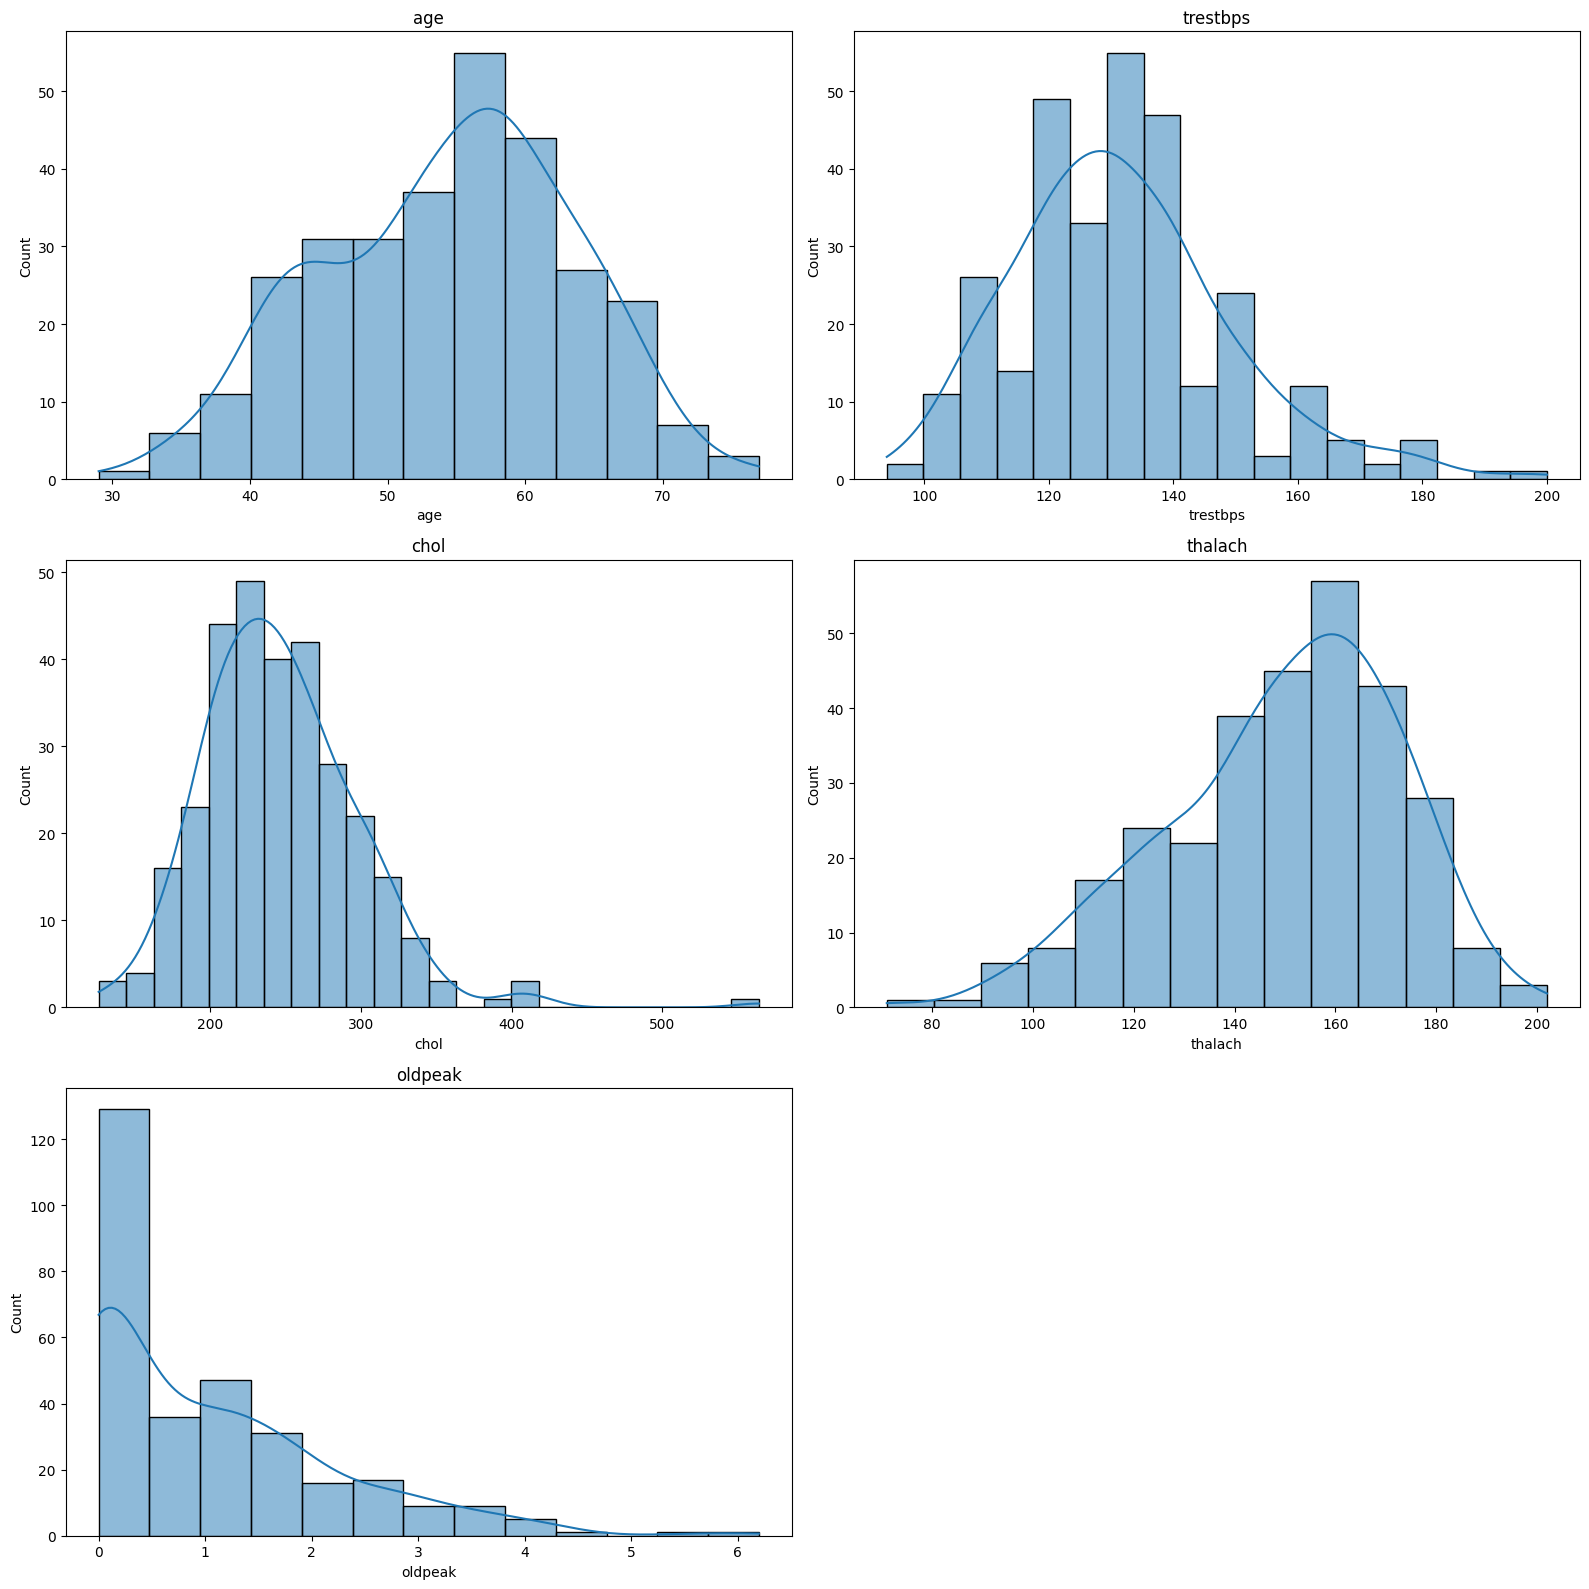

In [24]:
plt.figure(figsize = (16, 16))
i = 1
for column in num_cols:
  plt.subplot(3, 2, i)
  sns.histplot(df_heart[column], kde=True)
  plt.title(column)
  i += 1
plt.tight_layout()
plt.show()

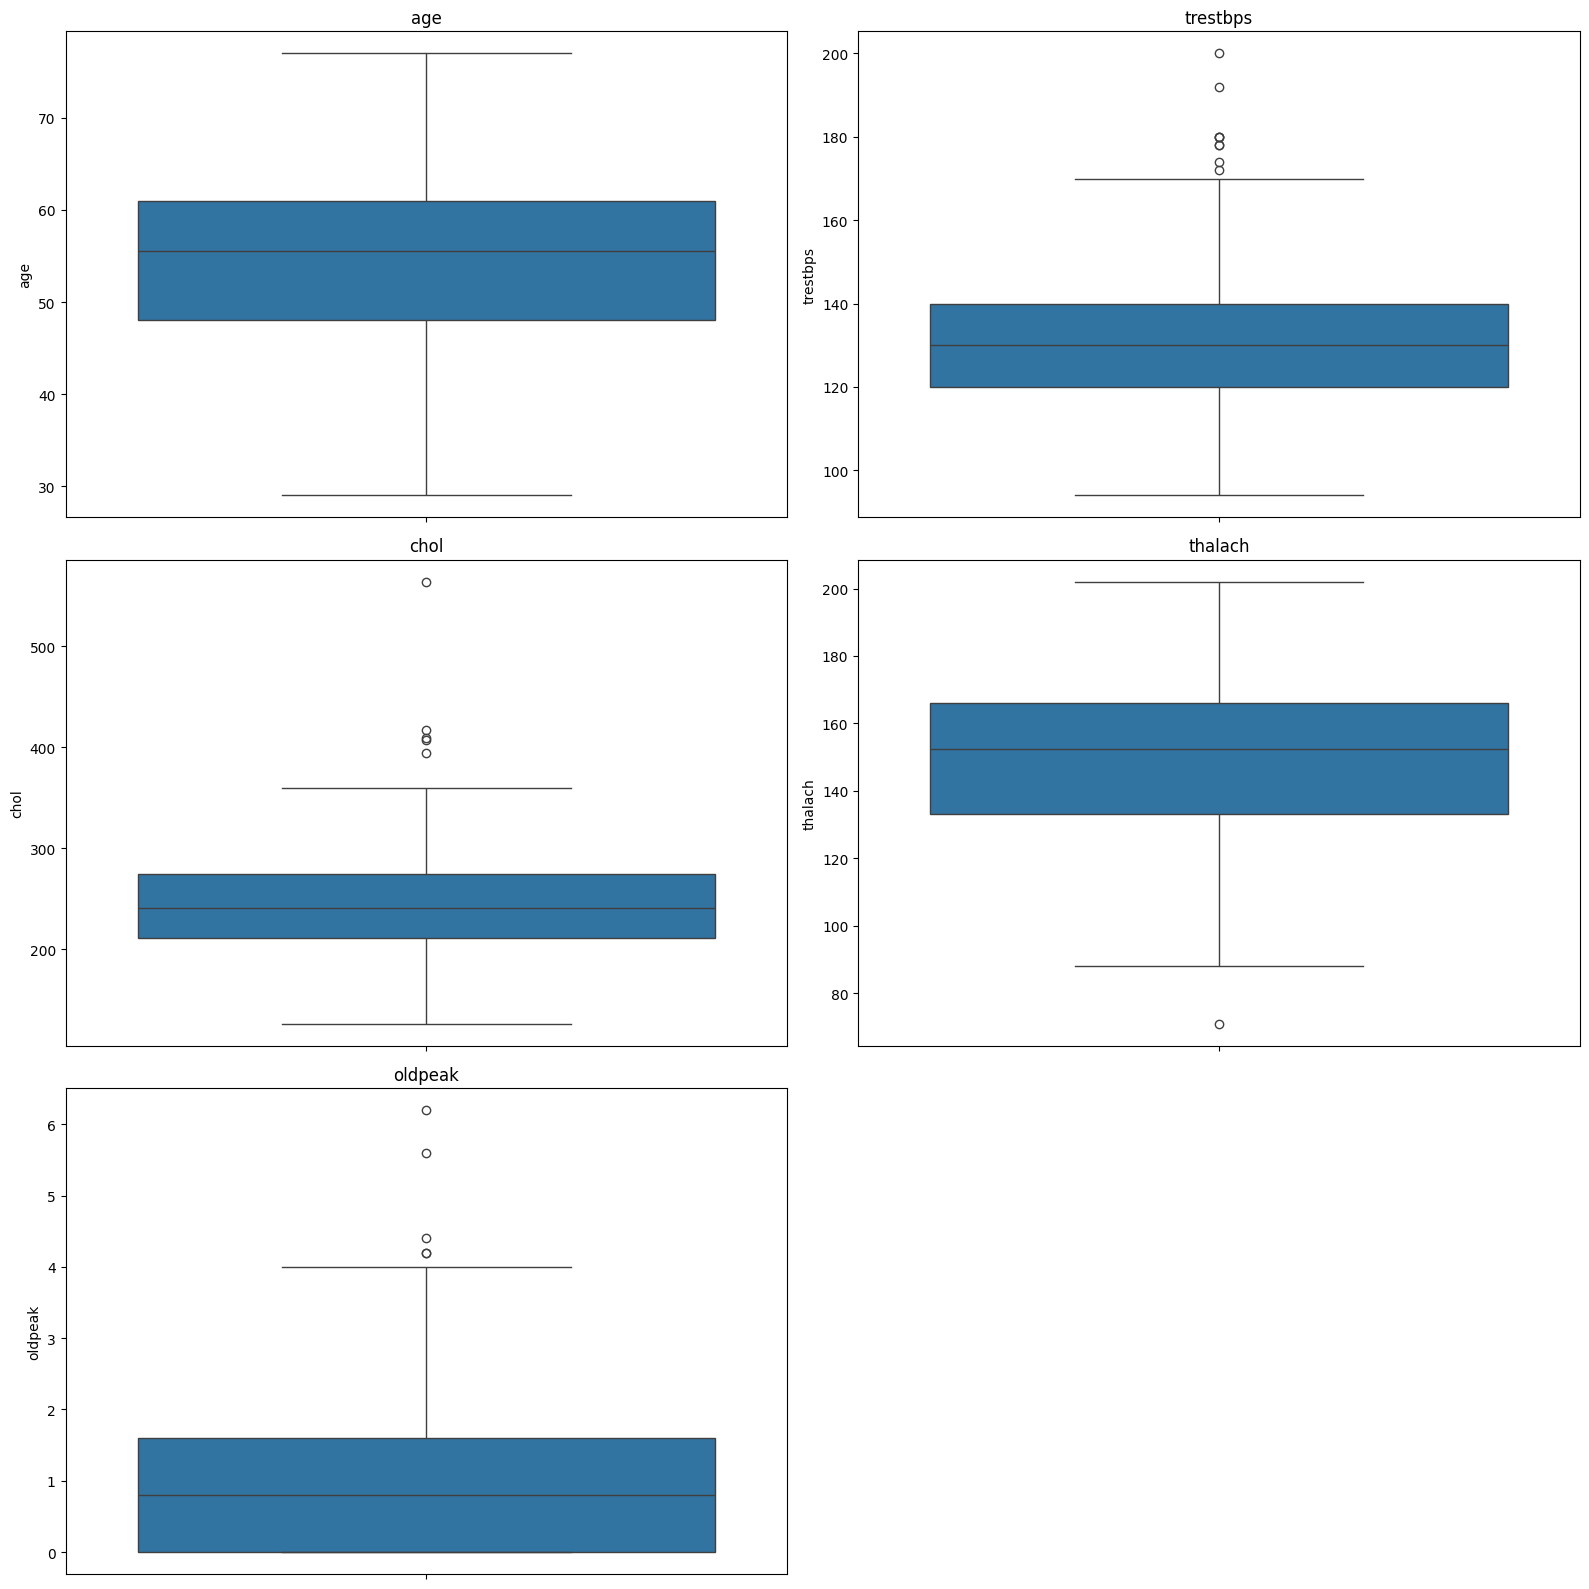

In [25]:
plt.figure(figsize = (16, 16))
i = 1
for column in num_cols:
  plt.subplot(3, 2, i)
  sns.boxplot(df_heart[column])
  plt.title(column)
  i += 1
plt.tight_layout()
plt.show()

In [31]:
# Checing the outliers with IQR

# chol
Q1 = df_heart['chol'].quantile(0.25)
Q3 = df_heart['chol'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# viewing outliers
outliers_chol = df_heart[(df_heart['chol'] > upper)]
outliers_chol

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
123,65,0,2,140,417,1,0,157,0,0.8,2,1,2,1
158,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
179,56,0,0,134,409,0,0,150,1,1.9,1,2,3,0
255,62,0,0,140,394,0,0,157,0,1.2,1,0,2,1
450,63,0,0,150,407,0,0,154,0,4.0,1,3,3,0


In [32]:
# trestbps
Q1 = df_heart['trestbps'].quantile(0.25)
Q3 = df_heart['trestbps'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# viewing outliers
outliers_trestbps = df_heart[(df_heart['trestbps'] > upper)]
outliers_trestbps

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
29,55,0,0,180,327,0,2,117,1,3.4,1,0,2,0
47,66,0,0,178,228,1,1,165,1,1.0,1,2,3,0
87,59,0,0,174,249,0,1,143,1,0.0,1,0,2,0
137,64,0,0,180,325,0,1,154,1,0.0,2,0,2,1
151,54,1,1,192,283,0,0,195,0,0.0,2,1,3,0
175,56,0,0,200,288,1,0,133,1,4.0,0,2,3,0
343,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
396,68,1,2,180,274,1,0,150,1,1.6,1,0,3,0
528,59,1,3,178,270,0,0,145,0,4.2,0,0,3,1


In [ ]:
# Inference:
'''
1. trestbps (Resting Blood Pressure)
    Few high-value outliers. But, these values (172–200 mmHg) represent clinically plausible cases of hypertension
    Therefore, the outliers were retained.

2. chol (Serum Cholesterol)
    Contains several high-value outliers as detected by the IQR method.
    The observed values (394–564 mg/dL) are medically possible
    no outlier treatment was applied

3. thalach (Maximum Heart Rate Achieved)
    Few outliers were detected.
    These values fall within physiologically possible limits
    Thus, the outliers were retained

4. oldpeak (ST Depression Induced by Exercise)
    Few high-value outliers due to its right-skewed distribution.
    These values indicate greater ST depression, which is clinically meaningful
    As they represent valid observations rather than anomalies, no outlier handling was performed
'''

## Encoding

In [35]:
# cols to be one-hot encoded are:
ohe_cols = ['cp', 'restecg', 'thal']

# binary feature cols are already encoded -> 'sex', 'fbs' and 'exang'

In [37]:
# Initialize encoder
ohe_obj = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Encode
encoded = ohe_obj.fit_transform(df_heart[ohe_cols])

# Create DataFrame with encoded column names
encoded_df = pd.DataFrame(
    encoded,
    columns = ohe_obj.get_feature_names_out(ohe_cols),
    index=df_heart.index
)

# Drop original columns and concatenate encoded columns
df_heart = pd.concat([df_heart.drop(columns = ohe_cols), encoded_df], axis=1)

df_heart.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,...,cp_1,cp_2,cp_3,restecg_0,restecg_1,restecg_2,thal_0,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,53,1,140,203,1,155,1,3.1,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,70,1,145,174,0,125,1,2.6,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,61,1,148,203,0,161,0,0.0,2,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,62,0,138,294,1,106,0,1.9,1,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## Scaling

In [39]:
# cols to be scaled are:
scale_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [41]:
# Initialize scaler
scaler = StandardScaler()

# Scale the selected columns
df_heart[scale_cols] = scaler.fit_transform(df_heart[scale_cols])

# Display the first few rows
df_heart.head(20)

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,...,cp_1,cp_2,cp_3,restecg_0,restecg_1,restecg_2,thal_0,thal_1,thal_2,thal_3
0,-0.267966,1,-0.376556,-0.667728,0,0.806035,0,-0.037124,2,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,-0.157260,1,0.478910,-0.841918,1,0.237495,1,1.773958,0,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.724733,1,0.764066,-1.403197,0,-1.074521,1,1.342748,0,0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.728383,1,0.935159,-0.841918,0,0.499898,0,-0.899544,2,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.839089,0,0.364848,0.919336,1,-1.905464,0,0.739054,1,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
5,0.396267,0,-1.802334,0.029032,0,-1.205722,0,-0.037124,1,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
6,0.396267,1,-1.003898,1.383842,0,-0.418513,0,2.895104,0,3,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
7,0.064151,1,1.619532,0.822564,0,-0.199843,1,-0.209608,1,1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
8,-0.932199,1,-0.661712,0.048386,0,-0.243577,0,-0.209608,2,0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
9,-0.046555,1,-0.547650,0.764500,0,-1.468126,1,1.860200,1,2,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


## TrainTestSplit

In [43]:
# Features and target
X = df_heart.drop(columns='target')
y = df_heart[target_col]    # target_col = 'target'

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check the shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (241, 21)
X_test : (61, 21)
y_train: (241,)
y_test : (61,)


## Logistic Regression

In [48]:
# Initialize model
lr = LogisticRegression(random_state=42)

# Train
lr.fit(X_train, y_train)

# Predict
y_pred_lr = lr.predict(X_test)

## KNN

In [49]:
# Initialize model
knn = KNeighborsClassifier(n_neighbors=5)

# Train
knn.fit(X_train, y_train)

# Predict
y_pred_knn = knn.predict(X_test)

## Random Forest

In [50]:
# Initialize model
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

## Evaluation Metrics:

In [51]:
print("Logistic Regression Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-Score :", f1_score(y_test, y_pred_lr))

print("******************************************** \n")

print("KNN Performance \n")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1-Score :", f1_score(y_test, y_pred_knn))

print("******************************************** \n")

print("Random Forest Performance \n")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1-Score :", f1_score(y_test, y_pred_rf))

Logistic Regression Performance
Accuracy : 0.8032786885245902
Precision: 0.8
Recall   : 0.8484848484848485
F1-Score : 0.8235294117647058
******************************************** 

KNN Performance 

Accuracy : 0.7704918032786885
Precision: 0.8064516129032258
Recall   : 0.7575757575757576
F1-Score : 0.78125
******************************************** 

Random Forest Performance 

Accuracy : 0.7704918032786885
Precision: 0.7714285714285715
Recall   : 0.8181818181818182
F1-Score : 0.7941176470588235


# **Regression**

In [ ]:
# For regression

num_cols = ['age', 'trestbps', 'thalach', 'oldpeak']
cat_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal','target']

target_col =  'chol'      # shouldn't scale, nor handle any outliers
# It shows -> Serum cholesterol: Cholesterol level (in mg/dl)  => Regression